# Object Oriented Programming in Python — A Complete Hands-On Lab

Welcome to this comprehensive, beginner-friendly lab on **Object-Oriented Programming (OOP)** in Python.
OOP is a programming *paradigm* — a way of thinking about and organising code — that models real-world entities as **objects** which have both *data* (attributes) and *behaviour* (methods).

## Real-World Problem We Will Solve

By the end of this lab you will have built a working **Clinic Management System** — a mini application that:

- Represents **Patients** and **Doctors** as proper objects with attributes and methods.
- Uses **Encapsulation** to protect sensitive medical records.
- Uses **Inheritance** so Doctors and Patients both share common `Person` behaviour.
- Uses **Polymorphism** so different appointment types calculate their fees differently.
- Ties everything together in a `ClinicManager` class that books appointments and prints daily billing summaries.

## Learning Objectives

After completing this lab you will be able to:

- Define and instantiate Python **classes and objects**.
- Write **constructors** (`__init__`) and distinguish instance vs. class attributes.
- Add **instance methods** and understand the role of `self`.
- Apply **encapsulation** with private attributes and `@property`.
- Build class **hierarchies** using inheritance and `super()`.
- Exploit **polymorphism** by overriding methods in subclasses.
- Use Python's **special (dunder) methods** to make objects feel natural.
- Assemble all four pillars into a coherent **real-world system**.

---

## Architecture Overview — The Four Pillars of OOP

Before diving into code, let's see the big picture. Every OOP concept belongs to one of four pillars.

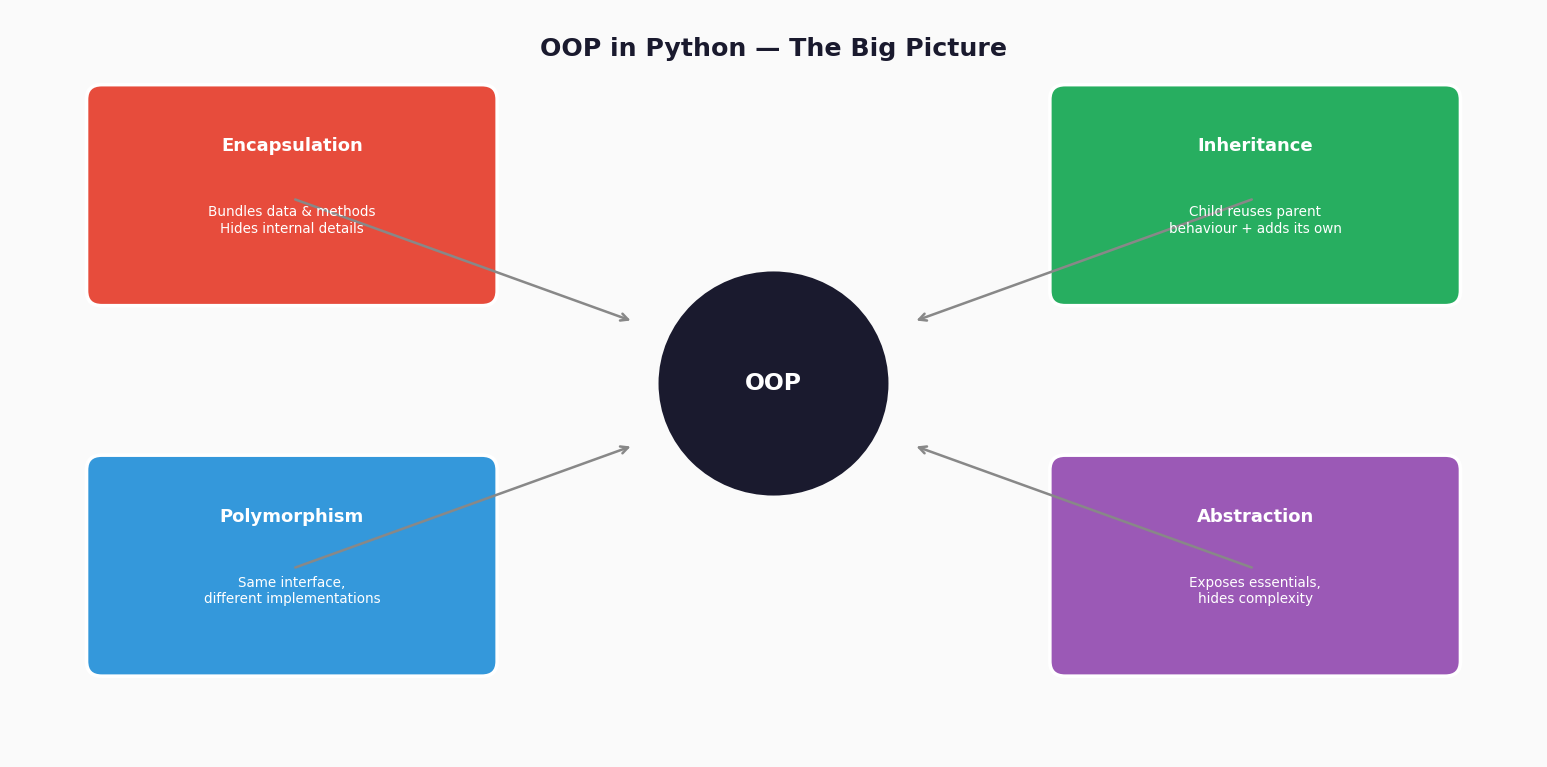

### How to Read This Diagram

| Pillar | Plain-English Summary |
|---|---|
| **Encapsulation** | Bundle related data and functions into one unit (the class). Hide private details behind a clean public interface. |
| **Inheritance** | Let a new class *inherit* data and behaviour from an existing class, then add or change what it needs. |
| **Polymorphism** | Write code that calls the *same method name* on different types of objects — each type responds appropriately. |
| **Abstraction** | Expose only what the caller *needs to know*; hide the complex internal implementation. |

Together these four pillars make large programs easier to write, understand, test, and maintain.

---

# 1. Classes and Objects — Blueprint & Instance

## What is a Class?

A **class** is like an architectural blueprint. It describes *what* something should look like and *what it can do*, without being that thing itself.

## What is an Object?

An **object** (or *instance*) is a concrete realisation of a class. You can create as many objects from one class as you like, and each carries its own independent data.

### Key Characteristics

| Concept | Description |
|---|---|
| **Class** | Template / blueprint — defines structure and behaviour |
| **Object** | A specific instance created from a class |
| **Attribute** | A variable that belongs to an object (its data) |
| **Method** | A function that belongs to an object (its behaviour) |
| **`self`** | The first parameter of every method — refers to the current object |

### The Class Structure & Object Instances

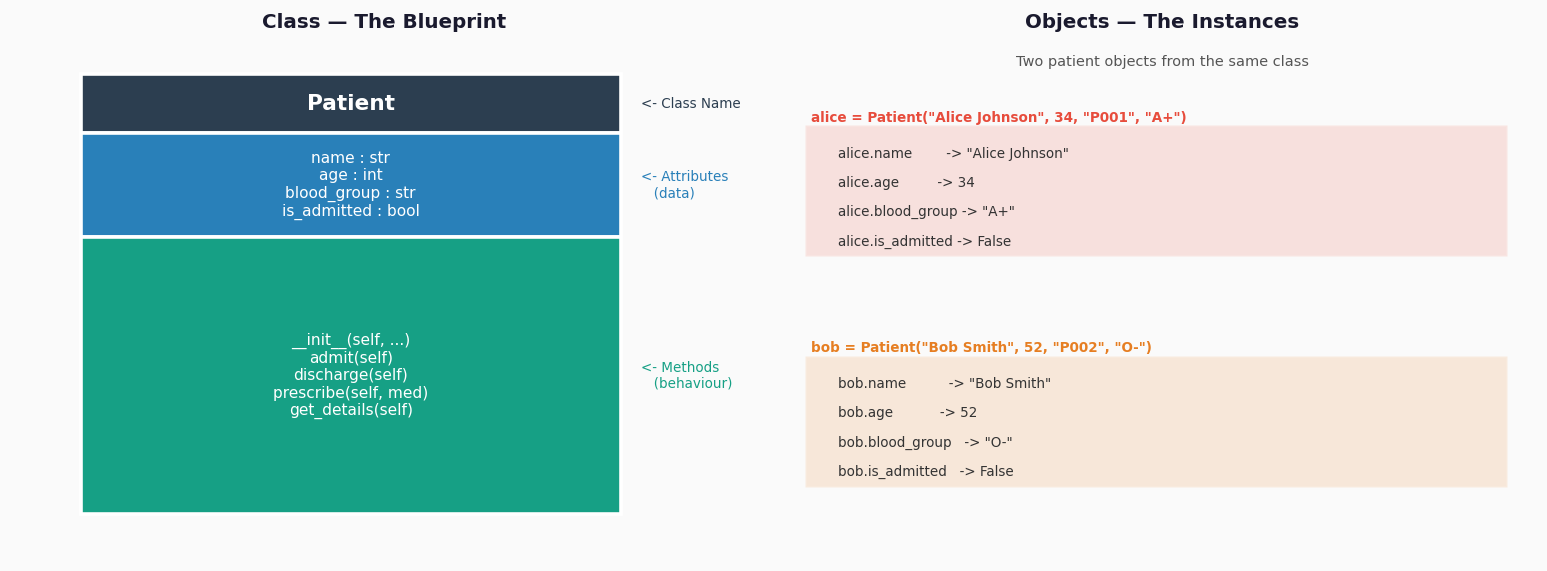

### Explanation of the Diagram

- The **left panel** shows the *class* — it is the blueprint. It has three sections: the class name (dark), the attributes it will store (blue), and the methods it can execute (green).
- The **right panel** shows two *objects* created from that class. Each holds independent data (Alice vs. Bob), but both have *exactly* the same structure and methods available.

---

### 1.1 Defining a Simple Class

Let's start with the simplest possible class — a `Person` — before building toward our clinic system.

In [ ]:
# ---- Defining a Class ----

class Person:
    # Class attribute -- shared by ALL instances of Person
    species = "Homo Sapiens"

    def __init__(self, name, age):
        # Instance attributes -- unique to EACH object
        self.name = name
        self.age  = age

    def greet(self):
        return f"Hi, I am {self.name} and I am {self.age} years old."

    def is_adult(self):
        return self.age >= 18


# ---- Creating objects (instances) ----
person1 = Person("Alice", 30)
person2 = Person("Bob", 16)

print(person1.greet())
print(person2.greet())
print(f"Is Alice an adult? {person1.is_adult()}")
print(f"Is Bob an adult?   {person2.is_adult()}")

# Class attribute accessed via the class OR via an instance
print(f"\nSpecies (via class)   : {Person.species}")
print(f"Species (via instance): {person1.species}")

# Each object stores independent data
print(f"\nperson1.name = '{person1.name}'")
print(f"person2.name = '{person2.name}'")
print(f"Same object? {person1 is person2}")

**Expected Output:**

```
Hi, I am Alice and I am 30 years old.
Hi, I am Bob and I am 16 years old.
Is Alice an adult? True
Is Bob an adult?   False

Species (via class)   : Homo Sapiens
Species (via instance): Homo Sapiens

person1.name = 'Alice'
person2.name = 'Bob'
Same object? False
```

### Code Explanation

- `class Person:` defines the blueprint. The body is indented exactly like `if`/`for` blocks.
- `species = "Homo Sapiens"` is a **class attribute** — it lives on the class itself. Every `Person` instance reads the same value unless explicitly overridden.
- `self.name` and `self.age` are **instance attributes** — each object has its own independent copy.
- `self` is always the first parameter of a method and refers to the object the method is being called on.
- `person1 is person2` is `False` because they are two *different objects* in memory, even though they come from the same blueprint.

---

### 1.2 Real-World Example: Your First Patient Object

In [ ]:
# ---- Real-World Example: Patient Object ----

class Patient:

    def __init__(self, name, age, patient_id, blood_group):
        self.name        = name
        self.age         = age
        self.patient_id  = patient_id
        self.blood_group = blood_group

    def get_summary(self):
        return (
            f"Patient : {self.name}\n"
            f"Age     : {self.age}\n"
            f"ID      : {self.patient_id}\n"
            f"Blood   : {self.blood_group}"
        )


# ---- Create patient objects ----
p1 = Patient("Alice Johnson", 34, "P001", "A+")
p2 = Patient("Bob Smith",     52, "P002", "O-")

print("--- Patient 1 ---")
print(p1.get_summary())

print("\n--- Patient 2 ---")
print(p2.get_summary())

print(f"\nBoth are Patient objects? {isinstance(p1, Patient) and isinstance(p2, Patient)}")

**Expected Output:**

```
--- Patient 1 ---
Patient : Alice Johnson
Age     : 34
ID      : P001
Blood   : A+

--- Patient 2 ---
Patient : Bob Smith
Age     : 52
ID      : P002
Blood   : O-

Both are Patient objects? True
```

### Code Explanation

- `isinstance(p1, Patient)` confirms that `p1` really is an instance of `Patient`.
- `p1` and `p2` share the same *structure* but hold entirely different data — this is the fundamental power of classes.

---

# 2. The `__init__` Constructor & Attributes

## What is `__init__`?

`__init__` is Python's **constructor** — a special method that runs *automatically* every time you create a new object. Its job is to set up the initial state (attributes) of that object.

### Key Characteristics

| Feature | Detail |
|---|---|
| **Called when** | `ClassName(args)` is evaluated |
| **First parameter** | Always `self` (the new object being constructed) |
| **Instance attributes** | Defined inside `__init__` with `self.attr = value` — unique per object |
| **Class attributes** | Defined in the class body (outside `__init__`) — shared across all instances |

### Instance vs. Class Attributes at a Glance

```python
class Patient:
    total_patients = 0          # <-- CLASS attribute (shared by all patients)

    def __init__(self, name):
        self.name = name        # <-- INSTANCE attribute (unique to each patient)
        Patient.total_patients += 1
```

---

### 2.1 Real-World Example: Full Patient Registration

In [ ]:
# ---- Full Patient __init__ with class & instance attributes ----

class Patient:

    # Class attribute -- keeps a running count of all registered patients
    total_patients = 0

    def __init__(self, name, age, patient_id, blood_group):
        # Instance attributes -- unique per patient
        self.name        = name
        self.age         = age
        self.patient_id  = patient_id
        self.blood_group = blood_group
        self.is_admitted = False   # default: not yet admitted
        self.medications = []      # empty list at registration

        # Increment the class-level counter whenever a new patient is created
        Patient.total_patients += 1

    def get_details(self):
        return {
            "Name"        : self.name,
            "Age"         : self.age,
            "Patient ID"  : self.patient_id,
            "Blood Group" : self.blood_group,
            "Admitted"    : self.is_admitted,
            "Medications" : self.medications or ["None"],
        }


# ---- Register three patients ----
p1 = Patient("Alice Johnson", 34, "P001", "A+")
p2 = Patient("Bob Smith",     52, "P002", "O-")
p3 = Patient("Priya Mehta",   28, "P003", "B+")

# Print details for each
for patient in [p1, p2, p3]:
    print(f"\n{'─' * 35}")
    for key, val in patient.get_details().items():
        print(f"  {key:<14}: {val}")

print(f"\n{'─' * 35}")
print(f"  Total patients registered: {Patient.total_patients}")

**Expected Output:**

```
───────────────────────────────────
  Name          : Alice Johnson
  Age           : 34
  Patient ID    : P001
  Blood Group   : A+
  Admitted      : False
  Medications   : ['None']

───────────────────────────────────
  Name          : Bob Smith
  ...

  Total patients registered: 3
```

### Code Explanation

| Line | Purpose |
|---|---|
| `total_patients = 0` | Class attribute — a counter shared by *every* `Patient` object |
| `self.is_admitted = False` | Sensible default; every patient starts as an outpatient |
| `self.medications = []` | Each patient gets their **own** empty list — not shared! |
| `Patient.total_patients += 1` | Every new patient object increments the class-level counter |

> **Common pitfall**: if you wrote `medications = []` at class level instead of inside `__init__`, *all* patients would share the same list — a nasty bug. Always put mutable defaults (lists, dicts) inside `__init__`.

---

# 3. Instance Methods and `self`

## What are Instance Methods?

**Instance methods** are functions defined inside a class that *operate on a specific object*. They always receive the object itself as their first argument — conventionally named `self`.

### Key Characteristics

| Property | Value |
|---|---|
| First parameter | Always `self` (the object the method is called on) |
| Access attributes | `self.attribute_name` |
| Call other methods | `self.other_method()` |
| Return values | Can return any value or nothing (`None`) |

---

### 3.1 Real-World Example: Patient Clinical Actions

In [ ]:
# ---- Instance Methods: Patient Clinical Workflow ----

class Patient:

    total_patients = 0

    def __init__(self, name, age, patient_id, blood_group):
        self.name        = name
        self.age         = age
        self.patient_id  = patient_id
        self.blood_group = blood_group
        self.is_admitted = False
        self.medications = []
        Patient.total_patients += 1

    # ── Action methods ──────────────────────────────────────────────────

    def admit(self):
        if not self.is_admitted:
            self.is_admitted = True
            return f"Admitted {self.name}."
        return f"Warning: {self.name} is already admitted."

    def discharge(self):
        if self.is_admitted:
            self.is_admitted = False
            self.medications = []          # clear prescriptions on discharge
            return f"Discharged {self.name}."
        return f"Warning: {self.name} is not currently admitted."

    def prescribe(self, medication):
        self.medications.append(medication)
        return f"Prescribed '{medication}' to {self.name}."

    def get_prescription(self):
        if self.medications:
            lines = "\n  ".join(
                f"{i+1}. {m}" for i, m in enumerate(self.medications)
            )
            return f"Prescription for {self.name}:\n  {lines}"
        return f"No active prescriptions for {self.name}."

    def status(self):
        state = "Admitted (In-patient)" if self.is_admitted else "Outpatient"
        return f"{self.name} [{self.patient_id}] -- {state}"


# ---- Demo ----
alice = Patient("Alice Johnson", 34, "P001", "A+")

print(alice.status())
print(alice.admit())
print(alice.admit())          # Try admitting again -- should warn

print()
print(alice.prescribe("Metformin 500mg"))
print(alice.prescribe("Lisinopril 10mg"))
print(alice.prescribe("Vitamin D 1000 IU"))

print()
print(alice.get_prescription())

print()
print(alice.discharge())
print(alice.status())
print(alice.get_prescription())   # Should show empty after discharge

**Expected Output:**

```
Alice Johnson [P001] -- Outpatient
Admitted Alice Johnson.
Warning: Alice Johnson is already admitted.

Prescribed 'Metformin 500mg' to Alice Johnson.
Prescribed 'Lisinopril 10mg' to Alice Johnson.
Prescribed 'Vitamin D 1000 IU' to Alice Johnson.

Prescription for Alice Johnson:
  1. Metformin 500mg
  2. Lisinopril 10mg
  3. Vitamin D 1000 IU

Discharged Alice Johnson.
Alice Johnson [P001] -- Outpatient
No active prescriptions for Alice Johnson.
```

### Code Explanation

| Method | What `self` does |
|---|---|
| `admit()` | Reads `self.is_admitted`, then **changes** it to `True` |
| `discharge()` | Changes `self.is_admitted` to `False` and **clears** `self.medications` |
| `prescribe(medication)` | **Appends** to `self.medications` |
| `get_prescription()` | **Reads** `self.medications` and formats a string |
| `status()` | **Reads** `self.name`, `self.patient_id`, and `self.is_admitted` |

Every method uses `self` to reach *the specific patient's own data* — that's what makes methods operate on individual objects rather than globally.

---

# 4. Encapsulation — Protecting Data

## What is Encapsulation?

**Encapsulation** is the practice of *bundling* data and methods into a class and *restricting direct access* to some of the object's components. This protects the object's internal state from accidental corruption by outside code.

### Python's Access Levels (by convention)

| Prefix | Meaning | Example |
|---|---|---|
| None | **Public** — anyone may read/write | `self.name` |
| Single underscore `_` | **Protected** — use with care (convention only) | `self._patient_id` |
| Double underscore `__` | **Private** — Python *mangles* the name to prevent easy access | `self.__medical_record` |

### The `@property` Decorator

`@property` lets you expose an attribute through a **getter** method that *looks like* plain attribute access. Pair it with `@attr.setter` to add **validation** when the value changes.

### Encapsulation Diagram

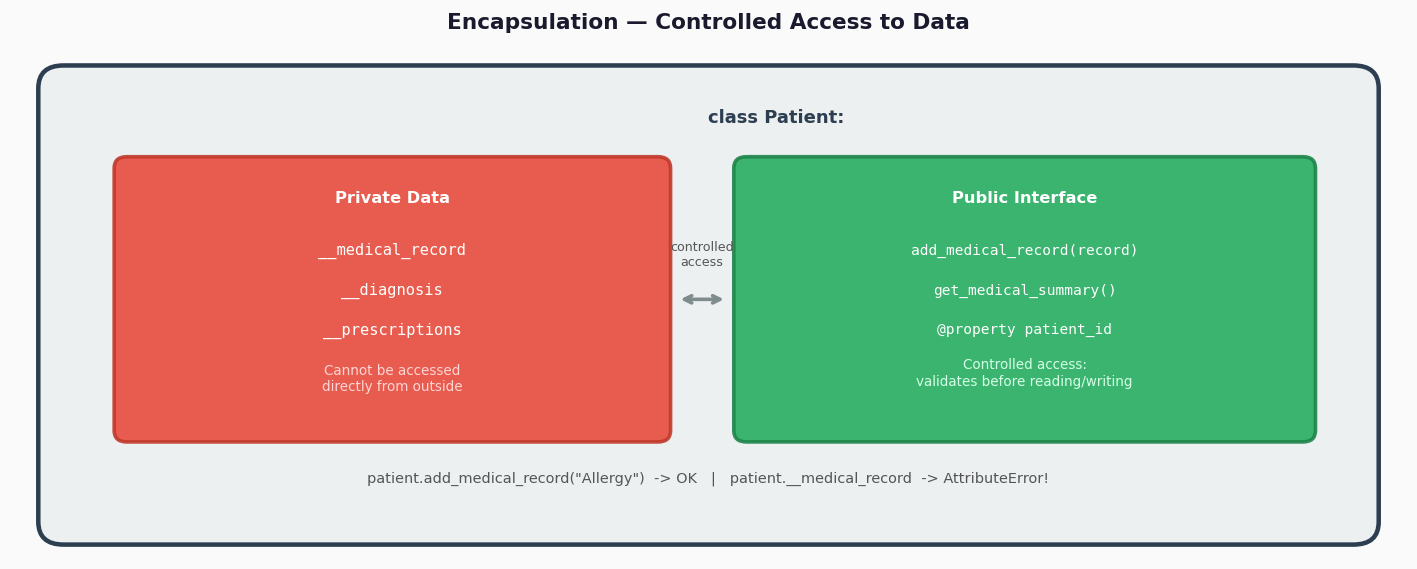

### Explanation of the Diagram

- The **red (private) box** contains data that should never be modified directly from outside the class. Python name-mangles `__attr` to `_ClassName__attr`, making direct access raise `AttributeError`.
- The **green (public) box** contains methods that the class *offers* as a controlled interface — they validate input before touching private data.
- External code can only interact through the public interface. This protects the integrity of the private data.

---

### 4.1 Real-World Example: Medical Record Privacy

In [ ]:
# ---- Encapsulation: Protecting the Medical Record ----

class Patient:

    def __init__(self, name, age, patient_id, blood_group):
        self.name          = name           # Public
        self.age           = age            # Public
        self.blood_group   = blood_group    # Public
        self._patient_id   = patient_id    # Protected (internal use)
        self.__medical_record = []         # Private (name-mangled)

    # ── Controlled interface to the private record ───────────────────────────

    def add_medical_record(self, record):
        if not isinstance(record, str) or not record.strip():
            return "Invalid record -- must be a non-empty string."
        self.__medical_record.append(record.strip())
        return f"Record added for {self.name}."

    def get_medical_summary(self):
        if not self.__medical_record:
            return f"No medical records on file for {self.name}."
        lines = "\n  ".join(
            f"{i+1}. {r}" for i, r in enumerate(self.__medical_record)
        )
        return f"Medical records for {self.name}:\n  {lines}"

    # ── @property: controlled access to patient_id ──────────────────────────

    @property
    def patient_id(self):
        return self._patient_id

    @patient_id.setter
    def patient_id(self, new_id):
        if isinstance(new_id, str) and new_id.startswith("P") and len(new_id) == 4:
            self._patient_id = new_id
            print(f"Patient ID updated to {new_id}")
        else:
            print("Invalid ID. Format must be P + 3 digits (e.g. P001).")


# ---- Demo ----
alice = Patient("Alice Johnson", 34, "P001", "A+")

print(alice.add_medical_record("Diagnosed: Type 2 Diabetes -- 2022"))
print(alice.add_medical_record("Blood pressure: 120/80 -- Normal"))
print(alice.add_medical_record("Known allergy: Penicillin"))
print(alice.add_medical_record(""))          # Invalid -- rejected

print()
print(alice.get_medical_summary())

# @property getter and setter
print(f"\nCurrent patient ID : {alice.patient_id}")   # getter
alice.patient_id = "P002"    # valid   -> accepted
alice.patient_id = "X99"     # invalid -> rejected

# Attempting direct access to the private attribute
print()
try:
    print(alice.__medical_record)
except AttributeError as e:
    print(f"Direct access blocked: {e}")

**Expected Output:**

```
Record added for Alice Johnson.
Record added for Alice Johnson.
Record added for Alice Johnson.
Invalid record -- must be a non-empty string.

Medical records for Alice Johnson:
  1. Diagnosed: Type 2 Diabetes -- 2022
  2. Blood pressure: 120/80 -- Normal
  3. Known allergy: Penicillin

Current patient ID : P001
Patient ID updated to P002
Invalid ID. Format must be P + 3 digits (e.g. P001).

Direct access blocked: 'Patient' object has no attribute '__medical_record'
```

### Code Explanation

| Feature | How it works |
|---|---|
| `self.__medical_record` | Python mangles this to `self._Patient__medical_record`, making `alice.__medical_record` raise `AttributeError` |
| `add_medical_record()` | Validates input before appending — external code *cannot bypass* the validation |
| `@property patient_id` | Looks like an attribute (`alice.patient_id`) but actually calls a method |
| `@patient_id.setter` | Called automatically when you write `alice.patient_id = "P002"` |

> **Why this matters in real systems**: medical records need strict access control. Without encapsulation, any part of the program could accidentally overwrite or corrupt critical patient data.

---

# 5. Inheritance — Building on Existing Classes

## What is Inheritance?

**Inheritance** lets a new class (the *child* or *derived* class) acquire the attributes and methods of an existing class (the *parent* or *base* class). You then add new attributes/methods or **override** existing ones to specialise the behaviour.

### Key Characteristics

| Concept | Meaning |
|---|---|
| `class Child(Parent)` | `Child` inherits everything from `Parent` |
| `super()` | Refers to the parent class — use it to call parent methods without repeating code |
| **Method overriding** | Redefine a parent method in the child to change its behaviour |
| `isinstance(obj, Class)` | Returns `True` if `obj` is an instance of `Class` or any of its subclasses |

### Inheritance Hierarchy for the Clinic

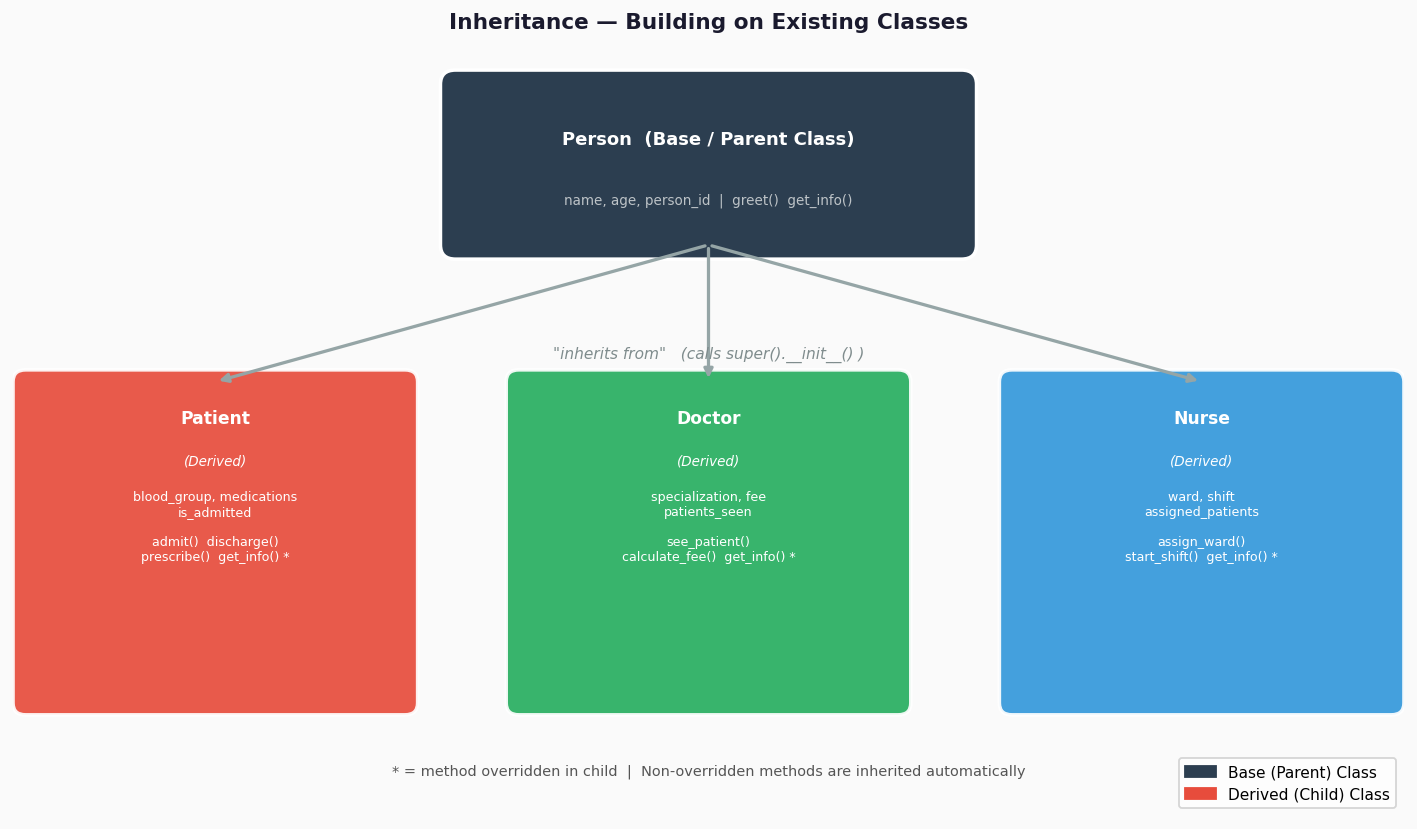

### Explanation of the Diagram

- `Person` is the **base class** — it contains data and behaviour common to *everyone* in the clinic.
- `Patient`, `Doctor`, and `Nurse` are **derived classes** — each inherits from `Person` and adds its own specialised attributes and methods.
- The `*` marks methods that *override* the parent's version.
- Non-overridden methods (like `greet()` in `Patient`) are inherited automatically.

---

### 5.1 Real-World Example: Clinic Staff Hierarchy

In [ ]:
# ---- Inheritance: Person -> Patient & Doctor ----

class Person:

    def __init__(self, name, age, person_id):
        self.name      = name
        self.age       = age
        self.person_id = person_id

    def greet(self):
        return f"Hello! My name is {self.name}."

    def get_info(self):
        return f"Name: {self.name} | Age: {self.age} | ID: {self.person_id}"


# ──────────────────────────────────────────────────────────────────────────────
class Patient(Person):

    total_registered = 0

    def __init__(self, name, age, patient_id, blood_group):
        super().__init__(name, age, patient_id)   # <-- call parent constructor
        self.blood_group = blood_group
        self.medications = []
        Patient.total_registered += 1

    def get_info(self):
        base = super().get_info()                 # <-- reuse parent string
        return f"{base} | Blood: {self.blood_group}"

    def prescribe(self, medication):
        self.medications.append(medication)
        return f"Prescribed {medication} to {self.name}."


# ──────────────────────────────────────────────────────────────────────────────
class Doctor(Person):

    def __init__(self, name, age, doctor_id, specialization, fee):
        super().__init__(name, age, doctor_id)
        self.specialization = specialization
        self.fee            = fee
        self._patients_seen = []

    def greet(self):
        return f"Hello! I am Dr. {self.name}, {self.specialization} specialist."

    def get_info(self):
        base = super().get_info()
        return f"Dr. {base} | Specialization: {self.specialization}"

    def see_patient(self, patient):
        self._patients_seen.append(patient.name)
        return f"Dr. {self.name} is now seeing {patient.name}."


# ─── Create instances ──────────────────────────────────────────────────────────
alice  = Patient("Alice Johnson", 34, "P001", "A+")
bob    = Patient("Bob Smith",     52, "P002", "O-")
dr_sar = Doctor("Sarah Ahmed",    45, "D001", "Cardiology", 1500)

print("─── Patient ───")
print(alice.greet())          # inherited from Person -- not overridden
print(alice.get_info())       # overridden in Patient
print(alice.prescribe("Aspirin 75mg"))

print("\n─── Doctor ───")
print(dr_sar.greet())         # overridden in Doctor
print(dr_sar.get_info())      # overridden in Doctor
print(dr_sar.see_patient(alice))

print("\n─── isinstance checks ───")
print(f"alice  is a Person?  {isinstance(alice,  Person)}")   # True
print(f"dr_sar is a Person?  {isinstance(dr_sar, Person)}")   # True
print(f"alice  is a Doctor?  {isinstance(alice,  Doctor)}")   # False
print(f"Total patients registered: {Patient.total_registered}")

**Expected Output:**

```
─── Patient ───
Hello! My name is Alice Johnson.
Name: Alice Johnson | Age: 34 | ID: P001 | Blood: A+
Prescribed Aspirin 75mg to Alice Johnson.

─── Doctor ───
Hello! I am Dr. Sarah Ahmed, Cardiology specialist.
Dr. Name: Sarah Ahmed | Age: 45 | ID: D001 | Specialization: Cardiology
Dr. Sarah Ahmed is now seeing Alice Johnson.

─── isinstance checks ───
alice  is a Person?  True
dr_sar is a Person?  True
alice  is a Doctor?  False
Total patients registered: 2
```

### Code Explanation

| Concept | Where to see it |
|---|---|
| `class Patient(Person)` | Patient inherits everything from Person |
| `super().__init__(...)` | Calls Person's constructor — avoids duplicating `self.name = name` etc. |
| `get_info()` override | Child rewrites the method; calls `super().get_info()` to reuse the parent's string |
| `greet()` override | Doctor adds the "Dr." title; Patient leaves `greet()` unchanged (pure inheritance) |
| `isinstance(alice, Person)` | `True` — a Patient *is also* a Person (the IS-A relationship) |

> **Rule of thumb**: Use inheritance when the relationship is truly IS-A ("A Patient IS-A Person"). For HAS-A relationships ("A Clinic HAS Patients"), use composition instead.

---

# 6. Polymorphism — One Interface, Many Behaviours

## What is Polymorphism?

**Polymorphism** (Greek: *poly* = many, *morphe* = form) means that different classes can be treated through the same interface — you call *the same method name* on objects of different types, and each type responds appropriately.

### Key Characteristics

| Aspect | Detail |
|---|---|
| **Method overriding** | Child redefines a parent method — the child's version is called |
| **Uniform interface** | Client code calls the same method regardless of the object's actual type |
| **`NotImplementedError`** | A base class can raise this to *force* subclasses to implement a method |
| **Duck typing** | Python's version: "if it has the method, it works" — no formal interface needed |

### Polymorphism in Action

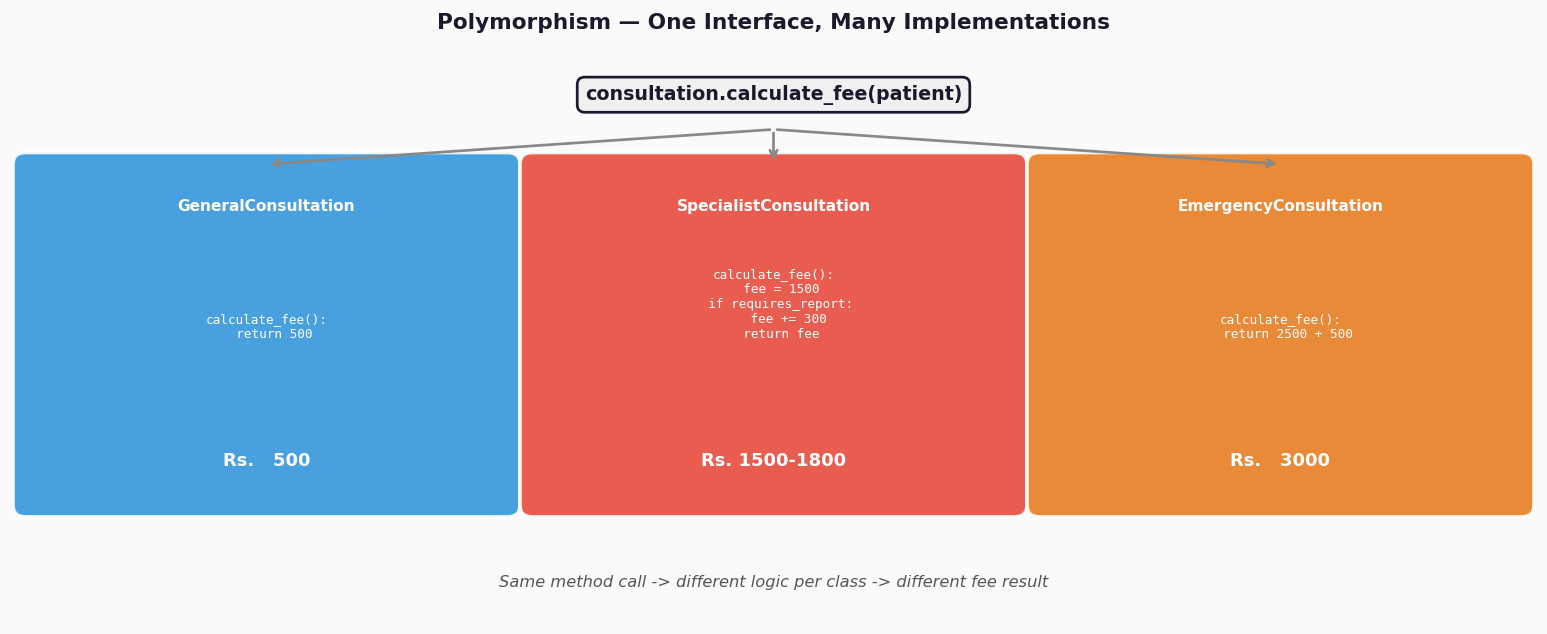

### Explanation of the Diagram

The calling code always runs `consultation.calculate_fee(patient)`. It does not care *which* type of consultation it holds. Each subclass implements its own calculation logic, so the same call yields a completely different result — that's polymorphism.

---

### 6.1 Real-World Example: Consultation Fee System

In [ ]:
# ---- Polymorphism: Appointment Fee Calculation ----

class ConsultationFee:

    def __init__(self, doctor_name, patient_name):
        self.doctor_name  = doctor_name
        self.patient_name = patient_name

    def calculate_fee(self):
        # Subclasses MUST override this -- acting as an abstract method
        raise NotImplementedError(
            f"{type(self).__name__} must implement calculate_fee()"
        )

    def generate_bill(self):
        # This template is written ONCE; it calls calculate_fee() polymorphically
        fee  = self.calculate_fee()
        kind = type(self).__name__
        return (
            f"\n{'=' * 40}\n"
            f"  {kind}\n"
            f"{'-' * 40}\n"
            f"  Doctor  : Dr. {self.doctor_name}\n"
            f"  Patient : {self.patient_name}\n"
            f"  Fee     : Rs. {fee:,.0f}\n"
            f"{'=' * 40}"
        )


class GeneralConsultation(ConsultationFee):
    BASE_FEE = 500

    def calculate_fee(self):
        return self.BASE_FEE


class SpecialistConsultation(ConsultationFee):
    BASE_FEE   = 1_500
    REPORT_FEE = 300

    def __init__(self, doctor_name, patient_name, requires_report=False):
        super().__init__(doctor_name, patient_name)
        self.requires_report = requires_report

    def calculate_fee(self):
        return self.BASE_FEE + (self.REPORT_FEE if self.requires_report else 0)


class EmergencyConsultation(ConsultationFee):
    BASE_FEE           = 2_500
    EMERGENCY_SURCHARGE = 500

    def calculate_fee(self):
        return self.BASE_FEE + self.EMERGENCY_SURCHARGE


# ---- Polymorphism demo: same loop, different results ----
appointments = [
    GeneralConsultation("Dr. Kumar",    "Alice Johnson"),
    SpecialistConsultation("Dr. Sarah Ahmed", "Bob Smith", requires_report=True),
    SpecialistConsultation("Dr. Sarah Ahmed", "Priya Mehta", requires_report=False),
    EmergencyConsultation("Dr. Raj Patel", "Charlie Brown"),
]

total = 0
for appt in appointments:
    print(appt.generate_bill())     # same method call every time -- different fee
    total += appt.calculate_fee()

print(f"\n  Total clinic revenue today: Rs. {total:,.0f}")

**Expected Output:**

```
========================================
  GeneralConsultation
----------------------------------------
  Doctor  : Dr. Dr. Kumar
  Patient : Alice Johnson
  Fee     : Rs. 500
========================================

========================================
  SpecialistConsultation
----------------------------------------
  Doctor  : Dr. Dr. Sarah Ahmed
  Patient : Bob Smith
  Fee     : Rs. 1,800
========================================
...

  Total clinic revenue today: Rs. 6,300
```

### Code Explanation

| Pattern | Purpose |
|---|---|
| `raise NotImplementedError` | Forces every subclass to provide `calculate_fee()` — acts like an abstract method |
| `generate_bill()` calls `self.calculate_fee()` | The billing template is written once in the base class; the correct `calculate_fee()` is selected automatically at runtime |
| Same `for appt in appointments:` loop | Works identically for every consultation type — this is polymorphism in practice |
| `type(self).__name__` | Returns the *actual* runtime class name for display |

> **Key insight**: Without polymorphism you would need `if isinstance(appt, General)... elif isinstance(appt, Specialist)...` everywhere — fragile and hard to extend. Polymorphism eliminates that.

---

# 7. Special Methods — Making Objects Feel Like Python Citizens

## What are Special (Dunder) Methods?

Python provides a set of **double-underscore methods** (nicknamed *dunder* methods or *magic methods*) that are called *implicitly* when you use built-in operators or functions on your objects. Implementing them makes your objects integrate naturally with Python syntax.

### Most Useful Dunder Methods

| Method | Called when you write | Typical use |
|---|---|---|
| `__str__(self)` | `print(obj)` or `str(obj)` | Human-readable description |
| `__repr__(self)` | `repr(obj)` or in the REPL | Unambiguous debug string |
| `__len__(self)` | `len(obj)` | Count of items |
| `__eq__(self, other)` | `obj1 == obj2` | Equality comparison |
| `__lt__(self, other)` | `obj1 < obj2` | Less-than comparison (enables `sorted()`) |

---

### 7.1 Real-World Example: Patient Card Display

In [ ]:
# ---- Special Methods: Patient with rich Python integration ----

class Patient:

    total_patients = 0

    def __init__(self, name, age, patient_id, blood_group):
        self.name        = name
        self.age         = age
        self.patient_id  = patient_id
        self.blood_group = blood_group
        self.medications = []
        Patient.total_patients += 1

    def prescribe(self, medication):
        self.medications.append(medication)

    def __str__(self):
        meds = ", ".join(self.medications) if self.medications else "None"
        return (
            f"+----- Patient Card -------------------+\n"
            f"|  Name        : {self.name:<23}|\n"
            f"|  Age         : {self.age:<23}|\n"
            f"|  Patient ID  : {self.patient_id:<23}|\n"
            f"|  Blood Group : {self.blood_group:<23}|\n"
            f"|  Medications : {meds:<23}|\n"
            f"+--------------------------------------+"
        )

    def __repr__(self):
        return (
            f"Patient(name={self.name!r}, age={self.age}, "
            f"patient_id={self.patient_id!r}, blood_group={self.blood_group!r})"
        )

    def __len__(self):
        return len(self.medications)

    def __eq__(self, other):
        if isinstance(other, Patient):
            return self.patient_id == other.patient_id
        return NotImplemented

    def __lt__(self, other):
        if isinstance(other, Patient):
            return self.age < other.age
        return NotImplemented


# ──────────────────────────────────────────────────────────────────────────────
p1 = Patient("Alice Johnson", 34, "P001", "A+")
p2 = Patient("Bob Smith",     52, "P002", "O-")
p3 = Patient("Alice Johnson", 34, "P001", "A+")   # same ID as p1

p1.prescribe("Metformin 500mg")
p1.prescribe("Vitamin D 1000 IU")
p1.prescribe("Lisinopril 10mg")

# __str__ -- called by print()
print("── __str__  (print) ──")
print(p1)

# __repr__ -- debug/REPL representation
print("\n── __repr__ (debug) ──")
print(repr(p1))

# __len__
print(f"\n── __len__  (len) ──")
print(f"Medications for {p1.name}: {len(p1)}")

# __eq__
print(f"\n── __eq__   (==) ──")
print(f"p1 == p2 : {p1 == p2}")   # Different IDs -> False
print(f"p1 == p3 : {p1 == p3}")   # Same ID     -> True

# __lt__ enables sorting
print(f"\n── __lt__   (sort) ──")
patients = [p1, p2, p3]
youngest_first = sorted(patients)
print("Patients sorted by age (youngest first):")
for p in youngest_first:
    print(f"  {p.name} -- age {p.age}")

**Expected Output:**

```
── __str__  (print) ──
+----- Patient Card -------------------+
|  Name        : Alice Johnson         |
|  Age         : 34                    |
|  Patient ID  : P001                  |
|  Blood Group : A+                    |
|  Medications : Metformin 500mg, ...  |
+--------------------------------------+

── __repr__ (debug) ──
Patient(name='Alice Johnson', age=34, patient_id='P001', blood_group='A+')

── __len__  (len) ──
Medications for Alice Johnson: 3

── __eq__   (==) ──
p1 == p2 : False
p1 == p3 : True

── __lt__   (sort) ──
Patients sorted by age (youngest first):
  Alice Johnson -- age 34
  Alice Johnson -- age 34
  Bob Smith -- age 52
```

### Code Explanation

| Method | What Python does automatically |
|---|---|
| `__str__` | Every `print(patient)` triggers this — you control what the user sees |
| `__repr__` | Should contain enough info to recreate the object; used in the REPL and `repr()` |
| `__len__` | `len(patient)` becomes the medication count — reads naturally |
| `__eq__` | `p1 == p3` compares by `patient_id`, not by memory address |
| `__lt__` | Returning `True`/`False` lets `sorted()`, `min()`, and `max()` work automatically |

> Once you implement `__lt__`, Python's `sorted()` works on your objects with zero extra code.

---

# 8. Final Project — Complete Clinic Management System

We now have all four OOP pillars plus special methods. Let's assemble everything into a working **Clinic Management System**.

### System Architecture

```
Person  (Base class)
   |
   +---- Patient        <- encapsulation, @property, __str__, __len__
   |
   +---- Doctor
            |
            +---- Specialist   <- overrides calculate_fee() polymorphically

ClinicManager            <- orchestrates: registers staff, books appointments,
                            generates billing summary
```

This mirrors a real-world design: each class is responsible for *one* thing (Single Responsibility Principle), and the `ClinicManager` acts as the coordinator.

---

In [ ]:
# ════════════════════════════════════════════════════════════════
#  PART A: Class Definitions
# ════════════════════════════════════════════════════════════════

class Person:

    def __init__(self, name, age, person_id):
        self.name      = name
        self.age       = age
        self.person_id = person_id

    def greet(self):
        return f"Hello, I am {self.name}."

    def get_info(self):
        return f"Name: {self.name} | Age: {self.age} | ID: {self.person_id}"

    def __repr__(self):
        return f"{type(self).__name__}({self.name!r}, {self.person_id!r})"


# ── Patient ───────────────────────────────────────────────────────────────────

class Patient(Person):

    total_registered = 0

    def __init__(self, name, age, patient_id, blood_group):
        super().__init__(name, age, patient_id)
        self.blood_group      = blood_group
        self.__medical_record = []          # private
        self.medications      = []
        self.is_admitted      = False
        Patient.total_registered += 1

    # Encapsulation: controlled record access
    def add_record(self, record):
        if isinstance(record, str) and record.strip():
            self.__medical_record.append(record.strip())
            return True
        return False

    def get_record_summary(self):
        if not self.__medical_record:
            return f"No records for {self.name}."
        lines = "\n  ".join(
            f"{i+1}. {r}" for i, r in enumerate(self.__medical_record)
        )
        return f"Medical records for {self.name}:\n  {lines}"

    # Overridden methods
    def get_info(self):
        return super().get_info() + f" | Blood: {self.blood_group}"

    def __str__(self):
        status = "Admitted" if self.is_admitted else "Outpatient"
        return f"[Patient] {self.name} ({self.person_id}) -- {status}"

    def __len__(self):
        return len(self.medications)

    def prescribe(self, med):
        self.medications.append(med)

    def admit(self):
        self.is_admitted = True

    def discharge(self):
        self.is_admitted = False


# ── Doctor + Specialist ───────────────────────────────────────────────────────

class Doctor(Person):

    BASE_FEE = 500

    def __init__(self, name, age, doctor_id, specialization, fee=None):
        super().__init__(name, age, doctor_id)
        self.specialization = specialization
        self.fee            = fee or self.BASE_FEE
        self._patients_seen = []

    def greet(self):
        return f"Hello, I am Dr. {self.name}, {self.specialization}."

    def get_info(self):
        return f"Dr. {super().get_info()} | {self.specialization}"

    def see_patient(self, patient):
        self._patients_seen.append(patient.person_id)

    def calculate_fee(self, follow_up=False, with_tests=False):
        return self.fee * (0.5 if follow_up else 1.0)

    def __str__(self):
        return f"[Doctor] Dr. {self.name} | {self.specialization} | Fee Rs.{self.fee}"


class Specialist(Doctor):

    TEST_FEE = 400

    def calculate_fee(self, follow_up=False, with_tests=False):
        base = super().calculate_fee(follow_up)
        return base + (self.TEST_FEE if with_tests else 0)


# ── Clinic Manager ────────────────────────────────────────────────────────────

class ClinicManager:

    def __init__(self, clinic_name):
        self.clinic_name    = clinic_name
        self._patients      = {}
        self._doctors       = {}
        self._appointments  = []
        self._total_revenue = 0.0

    def register_patient(self, patient):
        self._patients[patient.person_id] = patient
        print(f"  Registered  {patient}")

    def add_doctor(self, doctor):
        self._doctors[doctor.person_id] = doctor
        print(f"  Added       {doctor}")

    def book_appointment(self, patient_id, doctor_id,
                         follow_up=False, with_tests=False):
        patient = self._patients.get(patient_id)
        doctor  = self._doctors.get(doctor_id)

        if patient is None or doctor is None:
            return "  Unknown patient or doctor ID."

        # Polymorphism: calculate_fee() works for Doctor and Specialist
        fee = doctor.calculate_fee(follow_up=follow_up, with_tests=with_tests)
        self._total_revenue += fee
        doctor.see_patient(patient)

        patient.add_record(
            f"Seen by Dr. {doctor.name} ({doctor.specialization}); fee Rs.{fee:.0f}"
        )
        self._appointments.append({
            "patient": patient.name,
            "doctor":  f"Dr. {doctor.name}",
            "type":    doctor.specialization,
            "follow_up": follow_up,
            "tests":   with_tests,
            "fee":     fee,
        })
        visit = "Follow-up" if follow_up else "New consult"
        return (
            f"  Appointment confirmed\n"
            f"    {patient.name}  ->  Dr. {doctor.name}  ({doctor.specialization})\n"
            f"    {visit}  |  Tests: {'Yes' if with_tests else 'No'}"
            f"  |  Fee: Rs. {fee:,.0f}"
        )

    def daily_summary(self):
        print(f"\n{'=' * 52}")
        print(f"  DAILY SUMMARY -- {self.clinic_name}")
        print(f"{'=' * 52}")
        print(f"  Patients registered : {Patient.total_registered}")
        print(f"  Appointments today  : {len(self._appointments)}")
        print(f"  Total revenue       : Rs. {self._total_revenue:,.0f}")
        print(f"\n  Appointments breakdown:")
        for i, a in enumerate(self._appointments, 1):
            flag = "(follow-up)" if a["follow_up"] else "(new)"
            print(f"  {i}. {a['patient']} -> {a['doctor']} "
                  f"[{a['type']}] {flag} -- Rs. {a['fee']:,.0f}")
        print(f"{'=' * 52}")

In [ ]:
# ════════════════════════════════════════════════════════════════
#  PART B: Running the Clinic for a Day
# ════════════════════════════════════════════════════════════════

clinic = ClinicManager("City Care Clinic")

# ── Register doctors ───────────────────────────────────────────────────────────
print("─── Registering Doctors ───")
dr_kumar = Doctor("Kumar",      45, "D001", "General Medicine", 500)
dr_sarah = Specialist("Sarah Ahmed", 40, "D002", "Cardiology",       1_500)
dr_raj   = Specialist("Raj Patel",   50, "D003", "Orthopedics",      1_200)

clinic.add_doctor(dr_kumar)
clinic.add_doctor(dr_sarah)
clinic.add_doctor(dr_raj)

# ── Register patients ──────────────────────────────────────────────────────────
print("\n─── Registering Patients ───")
alice = Patient("Alice Johnson", 34, "P001", "A+")
bob   = Patient("Bob Smith",     52, "P002", "O-")
priya = Patient("Priya Mehta",   28, "P003", "B+")

alice.add_record("History: Type 2 Diabetes -- 2022")
bob.add_record("History: Hypertension -- 2019")

clinic.register_patient(alice)
clinic.register_patient(bob)
clinic.register_patient(priya)

# ── Book appointments (polymorphism in action) ─────────────────────────────────
print("\n─── Booking Appointments ───")
print(clinic.book_appointment("P001", "D001"))                        # General
print(clinic.book_appointment("P001", "D002", with_tests=True))       # Specialist + tests
print(clinic.book_appointment("P002", "D002", follow_up=True))        # Follow-up
print(clinic.book_appointment("P003", "D003"))                        # Specialist
print(clinic.book_appointment("P002", "D001", follow_up=True))        # Follow-up general

# ── Demonstrate special methods ────────────────────────────────────────────────
print("\n─── Patient Card (via __str__) ───")
alice.prescribe("Metformin 500mg")
alice.prescribe("Vitamin D 1000 IU")
print(alice)
print(f"Medications count (len): {len(alice)}")

print("\n─── Medical Records (encapsulation) ───")
print(alice.get_record_summary())

# ── Print daily summary ────────────────────────────────────────────────────────
clinic.daily_summary()

### What We Built and How OOP Made It Possible

| OOP Pillar | How It Was Applied |
|---|---|
| **Classes & Objects** | `Person`, `Patient`, `Doctor`, `Specialist`, `ClinicManager` each model a real-world entity |
| **Encapsulation** | `Patient.__medical_record` is private; access only through `add_record()` and `get_record_summary()` |
| **Inheritance** | `Patient` and `Doctor` inherit from `Person`; `Specialist` extends `Doctor` adding test-fee logic |
| **Polymorphism** | `calculate_fee()` called identically for `Doctor` and `Specialist` — different result per type |
| **Special methods** | `__str__` prints patient cards; `__len__` counts medications; `__repr__` aids debugging |

---

## Summary — OOP Quick Reference

```python
# Defining a class
class ClassName:
    class_attr = value          # Shared by all instances

    def __init__(self, arg):    # Constructor
        self.instance_attr = arg

    def method(self):           # Instance method
        return self.instance_attr

# Encapsulation
    self.__private = value      # Name-mangled to _ClassName__private
    @property
    def attr(self): return self.__private
    @attr.setter
    def attr(self, v): self.__private = v

# Inheritance
class Child(Parent):
    def __init__(self, ...):
        super().__init__(...)   # Call parent constructor
    def method(self):           # Override parent method
        base = super().method()

# Special methods
    def __str__(self):  ...     # print(obj)
    def __repr__(self): ...     # repr(obj)
    def __len__(self):  ...     # len(obj)
    def __eq__(self, o): ...    # obj1 == obj2
    def __lt__(self, o): ...    # obj1 < obj2  (enables sorted())
```

**Congratulations!** You have completed the OOP lab and built a working clinic management system from scratch using all four pillars of object-oriented design.